# Лабораторная работа №2-3  
## Логистическая регрессия. Оценка одобрения кредита (LoanApproved)

**Цель работы:**  
Обучить модель логистической регрессии для предсказания вероятности одобрения кредита `LoanApproved` по кредитным данным клиентов и добиться качества **ROC-AUC > 0.75** на валидационной выборке.

**Данные:**

- `train_c.csv` — обучающая выборка с целевой переменной `LoanApproved`;
- `test_c.csv` — тестовая выборка без `LoanApproved` (нужно сделать предсказания и подготовить файл сабмишена).

**Основная метрика:** ROC-AUC.  
Дополнительно считаем PR-AUC, Precision, Recall, F1-score.

**План работы:**

1. Импорты и загрузка данных.  
2. Первичный анализ и базовые статистики.  
3. Разведочный анализ данных (EDA): распределения, корреляции, интересные срезы.  
4. Признаки и препроцессинг (даты, числовые, категориальные).  
5. Базовая модель `LogisticRegression` и качество на валидации.  
6. Подбор гиперпараметров Logistic Regression (GridSearchCV).  
7. Финальная модель, обучение на всём train и предсказания для test.  
8. Подготовка файла сабмишена и выводы.


## 1. Импорты и загрузка данных

In [32]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# чтобы графики были покрупнее
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

train_path = "train_c.csv"
test_path = "test_c.csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print("Форма train:", df_train.shape)
print("Форма test:", df_test.shape)

print("\nИнфо по train:")
print(df_train.info())

print("\nИнфо по test:")
print(df_test.info())

Форма train: (11017, 35)
Форма test: (5000, 35)

Инфо по train:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries 

## 2. Первичный анализ и базовые статистики

### 2.1. Первые строки train

In [33]:
df_train.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,4.0,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,0.0
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,2.0,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,1.0
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,3.0,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,1.0
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,3.0,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,1.0
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,5.0,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,1.0


### 2.2. Статистики по числовым признакам

In [34]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,10487.0,39.850386,11.614132,18.000000,32.000000,40.000000,48.000000,8.000000e+01
AnnualIncome,10487.0,131587.872127,115791.941909,15000.000000,20959.500000,89015.000000,257025.000000,7.485080e+05
CreditScore,9986.0,678.082716,175.192486,300.000000,550.000000,722.500000,850.000000,8.500000e+02
LoanAmount,9986.0,29874.218306,27705.509722,1063.000000,12658.000000,21828.500000,37158.000000,4.189970e+05
LoanDuration,10487.0,53.439878,24.493562,12.000000,36.000000,48.000000,60.000000,1.200000e+02
NumberOfDependents,10487.0,1.568323,1.418684,0.000000,0.000000,1.000000,3.000000,6.000000e+00
MonthlyDebtPayments,9986.0,546.458642,501.981888,13.000000,233.250000,398.000000,685.000000,1.087900e+04
CreditCardUtilizationRate,10487.0,0.284397,0.159240,0.003674,0.158929,0.262229,0.391683,9.146347e-01
NumberOfOpenCreditLines,10487.0,3.033565,1.740186,0.000000,2.000000,3.000000,4.000000,1.200000e+01
NumberOfCreditInquiries,10487.0,0.979498,0.990927,0.000000,0.000000,1.000000,2.000000,6.000000e+00


### 2.3. Пропуски в train

In [35]:
missing_train = (
    df_train.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
    .assign(
        missing_percent=lambda d: 100 * d["missing_count"] / len(df_train)
    )
)
missing_train

,missing_count,missing_percent
MonthlyDebtPayments,1031,9.358265
LoanAmount,1031,9.358265
CreditScore,1031,9.358265
BaseInterestRate,1031,9.358265
NetWorth,1031,9.358265
TotalAssets,1031,9.358265
BankruptcyHistory,1031,9.358265
LoanPurpose,1031,9.358265
CheckingAccountBalance,1031,9.358265
ApplicationDate,530,4.810747


### 2.4. Пропуски в test


In [36]:
missing_test = (
    df_test.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
    .assign(
        missing_percent=lambda d: 100 * d["missing_count"] / len(df_test)
    )
)
missing_test

,missing_count,missing_percent
ID,0,0.0
ApplicationDate,0,0.0
Age,0,0.0
AnnualIncome,0,0.0
CreditScore,0,0.0
LoanAmount,0,0.0
LoanDuration,0,0.0
MaritalStatus,0,0.0
NumberOfDependents,0,0.0
HomeOwnershipStatus,0,0.0


### 2.5. Распределение целевой переменной LoanApproved

In [37]:
target_col = "LoanApproved"

print(df_train[target_col].value_counts())
print("\nДоля классов:")
df_train[target_col].value_counts(normalize=True)

LoanApproved
1.0    5367
0.0    5120
Name: count, dtype: int64

Доля классов:


,proportion
LoanApproved,
1.0,0.511776
0.0,0.488224


### 2.6. Сравнение колонок train и test (без target)

In [38]:
train_features = df_train.drop(columns=[target_col])
test_features = df_test.copy()

print("Совпадают ли имена признаков (без LoanApproved) в train и test?",
      train_features.columns.equals(test_features.columns))
print("\nКоличество столбцов в train_features:", train_features.shape[1])
print("Количество столбцов в test_features:", test_features.shape[1])

Совпадают ли имена признаков (без LoanApproved) в train и test? False

Количество столбцов в train_features: 34
Количество столбцов в test_features: 35


## 3. Разведочный анализ данных (EDA)

### 3.1. Корреляция числовых признаков

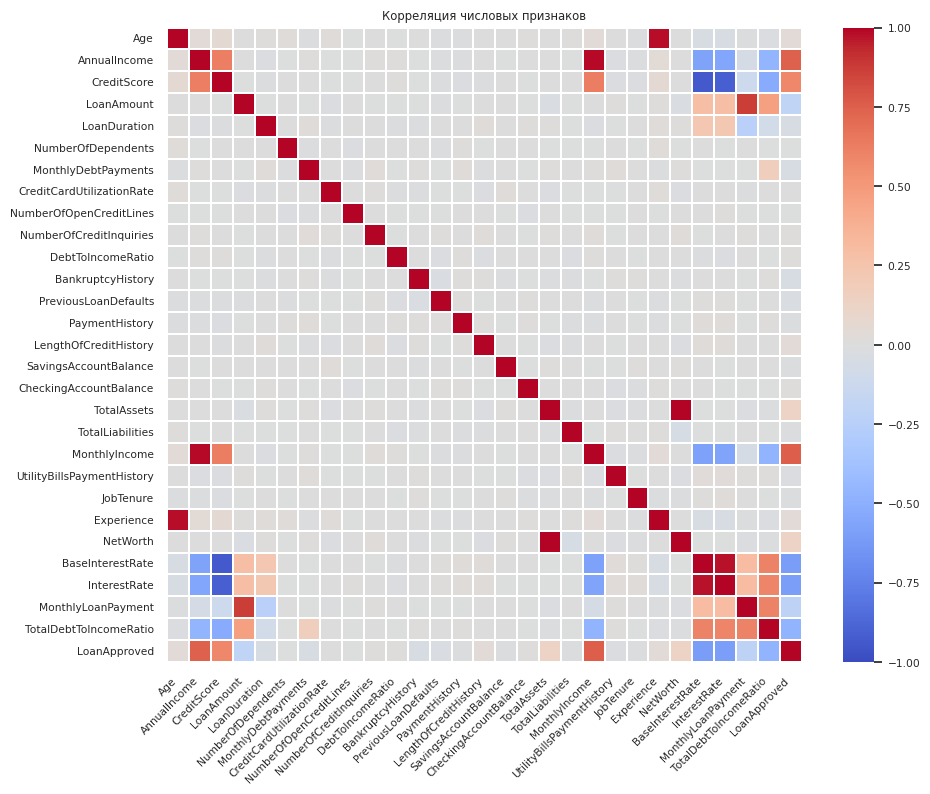

In [39]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df_train.select_dtypes(include=[np.number]).columns
corr = df_train[numeric_cols].corr()

plt.figure(figsize=(10, 8))

plt.grid(False)

sns.heatmap(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    linecolor="white"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Корреляция числовых признаков")
plt.tight_layout()
plt.show()


### 3.3. Интересные срезы по категориальным признакам

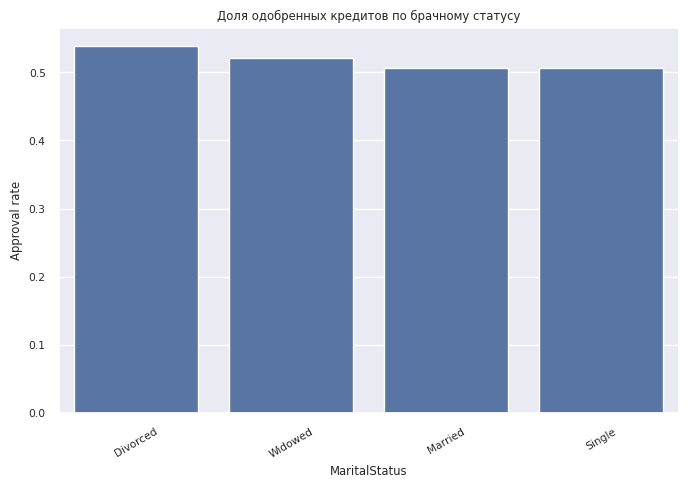

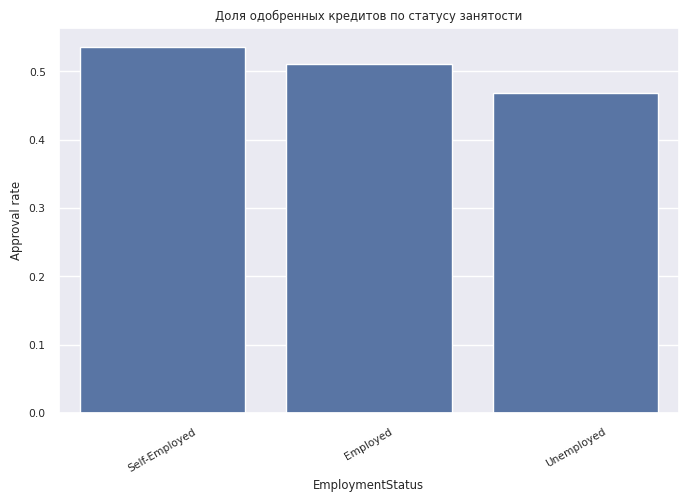

In [40]:
cat_cols_base = [
    "MaritalStatus",
    "HomeOwnershipStatus",
    "LoanPurpose",
    "EmploymentStatus",
    "EducationLevel",
]

cat_cols_base

# Посмотрим одобрение по брачному статусу
approval_by_marital = (
    df_train
    .groupby("MaritalStatus")[target_col]
    .agg(["mean", "count"])
    .rename(columns={"mean": "approval_rate", "count": "n"})
    .sort_values("approval_rate", ascending=False)
)
approval_by_marital

plt.figure()
sns.barplot(
    data=approval_by_marital.reset_index(),
    x="MaritalStatus",
    y="approval_rate"
)
plt.title("Доля одобренных кредитов по брачному статусу")
plt.xticks(rotation=30)
plt.ylabel("Approval rate")
plt.show()

approval_by_employment = (
    df_train
    .groupby("EmploymentStatus")[target_col]
    .agg(["mean", "count"])
    .rename(columns={"mean": "approval_rate", "count": "n"})
    .sort_values("approval_rate", ascending=False)
)
approval_by_employment

plt.figure()
sns.barplot(
    data=approval_by_employment.reset_index(),
    x="EmploymentStatus",
    y="approval_rate"
)
plt.title("Доля одобренных кредитов по статусу занятости")
plt.xticks(rotation=30)
plt.ylabel("Approval rate")
plt.show()

## 4. Признаки и препроцессинг

### 4.1. Функция для работы с датой и генерации новых признаков

In [41]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Переводим ApplicationDate в datetime
df_train["ApplicationDate"] = pd.to_datetime(df_train["ApplicationDate"])
df_test["ApplicationDate"] = pd.to_datetime(df_test["ApplicationDate"])

def add_date_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Добавляем признаки из ApplicationDate:
    - ApplicationYear
    - ApplicationMonth
    - ApplicationDayOfWeek
    и удаляем исходную колонку ApplicationDate.
    """
    df = df.copy()
    df["ApplicationYear"] = df["ApplicationDate"].dt.year
    df["ApplicationMonth"] = df["ApplicationDate"].dt.month
    df["ApplicationDayOfWeek"] = df["ApplicationDate"].dt.dayofweek
    return df.drop(columns=["ApplicationDate"])

# Применяем функцию к train и test
df_train_processed = add_date_features(df_train)
df_test_processed = add_date_features(df_test)

print("Форма df_train_processed:", df_train_processed.shape)
print("Форма df_test_processed:", df_test_processed.shape)

print("\nТипы данных после преобразования:")
df_train_processed.dtypes

Форма df_train_processed: (11017, 37)
Форма df_test_processed: (5000, 37)

Типы данных после преобразования:


,0
Age,float64
AnnualIncome,float64
CreditScore,float64
LoanAmount,float64
LoanDuration,float64
MaritalStatus,object
NumberOfDependents,float64
HomeOwnershipStatus,object
MonthlyDebtPayments,float64
CreditCardUtilizationRate,float64


### 4.2. Определяем списки числовых и категориальных признаков

In [42]:
categorical_features = [
    "MaritalStatus",
    "HomeOwnershipStatus",
    "LoanPurpose",
    "EmploymentStatus",
    "EducationLevel",
]

# Числовые признаки: все числовые, кроме целевой и ID (и категориальных)
numeric_features = [
    col for col in df_train_processed.columns
    if col not in categorical_features + [target_col, "ID"]
]

print(f"Числовых признаков: {len(numeric_features)}")
print(f"Категориальных признаков: {len(categorical_features)}")
print("Примеры числовых:", numeric_features[:10])

Числовых признаков: 31
Категориальных признаков: 5
Примеры числовых: ['Age', 'AnnualIncome', 'CreditScore', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries']


### 4.3. Трансформеры и ColumnTransformer

In [43]:
# Трансформер для числовых признаков: median + StandardScaler
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Трансформер для категориальных признаков: most_frequent + OneHotEncoder
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

# ColumnTransformer, объединяющий все
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("Preprocessor готов.")

Preprocessor готов.


## 5. Разбиение на train/valid и базовая модель LogisticRegression

### 5.1. X, y и очистка NaN в target

In [44]:
X = df_train_processed.drop(columns=[target_col])
y = df_train_processed[target_col]

print("Форма X:", X.shape)
print("Форма y:", y.shape)
print("Пропуски в y:", y.isna().sum())

# Удалим строки, где y = NaN
mask = y.notna()
X_clean = X[mask]
y_clean = y[mask]

print("\nПосле удаления NaN в y:")
print("Форма X_clean:", X_clean.shape)
print("Форма y_clean:", y_clean.shape)
print("Распределение классов:")
y_clean.value_counts(normalize=True)

Форма X: (11017, 36)
Форма y: (11017,)
Пропуски в y: 530

После удаления NaN в y:
Форма X_clean: (10487, 36)
Форма y_clean: (10487,)
Распределение классов:


,proportion
LoanApproved,
1.0,0.511776
0.0,0.488224


### 5.2. train/valid split

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

print("Форма X_train:", X_train.shape)
print("Форма X_val:", X_val.shape)
print("Распределение классов в y_train:")
print(y_train.value_counts(normalize=True))
print("\nРаспределение классов в y_val:")
print(y_val.value_counts(normalize=True))

Форма X_train: (8389, 36)
Форма X_val: (2098, 36)
Распределение классов в y_train:
LoanApproved
1.0    0.511742
0.0    0.488258
Name: proportion, dtype: float64

Распределение классов в y_val:
LoanApproved
1.0    0.511916
0.0    0.488084
Name: proportion, dtype: float64


### 5.3. Базовый пайплайн LogisticRegression

In [46]:
from sklearn.linear_model import LogisticRegression

base_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

base_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", base_model),
])

base_pipeline.fit(X_train, y_train)
print("Базовая модель обучена.")

Базовая модель обучена.


### 5.4. Метрики базовой модели + ROC / PR кривые и матрица ошибок

Базовая модель — метрики на валидации:
ROC-AUC: 0.9820
PR-AUC:  0.9840
Precision: 0.9333
Recall:    0.9246
F1-score:  0.9289


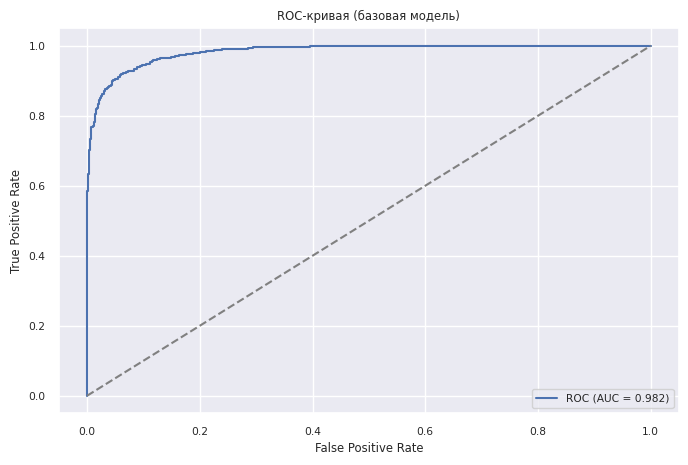

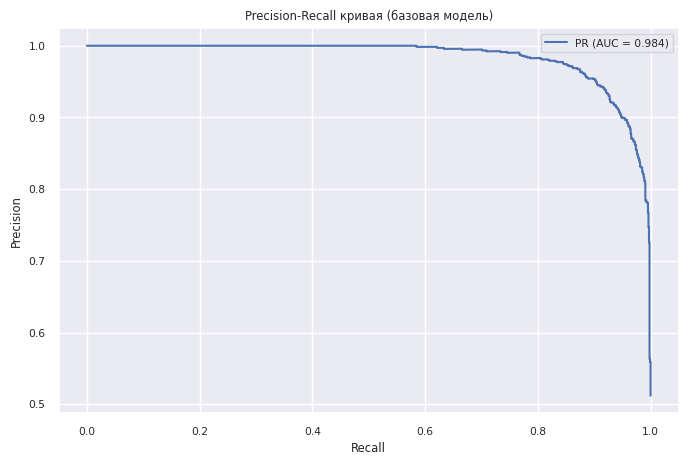

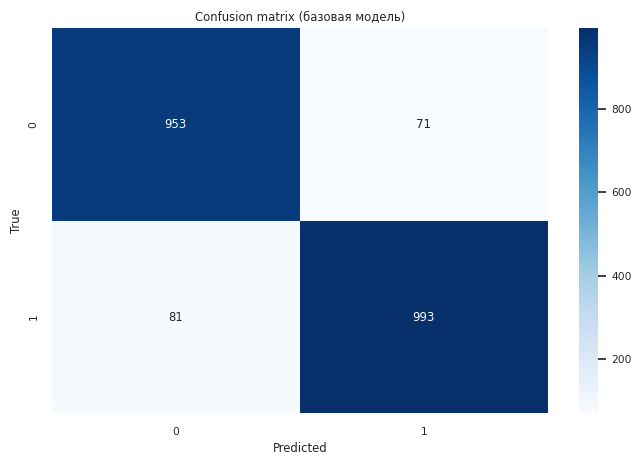

In [48]:
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix
)

y_val_proba_base = base_pipeline.predict_proba(X_val)[:, 1]
y_val_pred_base = base_pipeline.predict(X_val)

roc_auc_base = roc_auc_score(y_val, y_val_proba_base)
pr_auc_base = average_precision_score(y_val, y_val_proba_base)
precision_base = precision_score(y_val, y_val_pred_base)
recall_base = recall_score(y_val, y_val_pred_base)
f1_base = f1_score(y_val, y_val_pred_base)

print("Базовая модель — метрики на валидации:")
print(f"ROC-AUC: {roc_auc_base:.4f}")
print(f"PR-AUC:  {pr_auc_base:.4f}")
print(f"Precision: {precision_base:.4f}")
print(f"Recall:    {recall_base:.4f}")
print(f"F1-score:  {f1_base:.4f}")

# ROC-кривая
fpr, tpr, _ = roc_curve(y_val, y_val_proba_base)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc_base:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая (базовая модель)")
plt.legend()
plt.show()

# PR-кривая
prec_curve, rec_curve, _ = precision_recall_curve(y_val, y_val_proba_base)

plt.figure()
plt.plot(rec_curve, prec_curve, label=f"PR (AUC = {pr_auc_base:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall кривая (базовая модель)")
plt.legend()
plt.show()

# Матрица ошибок
cm = confusion_matrix(y_val, y_val_pred_base)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix (базовая модель)")
plt.show()

## 6. Подбор гиперпараметров LogisticRegression (GridSearchCV)

In [49]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear"],
}

grid_search = GridSearchCV(
    base_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)

print("Запускаем GridSearchCV...")
grid_search.fit(X_train, y_train)
print("GridSearchCV завершен.")

print("Лучшие параметры:", grid_search.best_params_)
print(f"Лучшая ROC-AUC на CV: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

Запускаем GridSearchCV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
GridSearchCV завершен.
Лучшие параметры: {'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Лучшая ROC-AUC на CV: 0.9857


### 6.1. Оценка лучшей модели на валидации

In [50]:
y_val_proba_best = best_model.predict_proba(X_val)[:, 1]
y_val_pred_best = best_model.predict(X_val)

roc_auc_best = roc_auc_score(y_val, y_val_proba_best)
pr_auc_best = average_precision_score(y_val, y_val_proba_best)
precision_best = precision_score(y_val, y_val_pred_best)
recall_best = recall_score(y_val, y_val_pred_best)
f1_best = f1_score(y_val, y_val_pred_best)

print("Лучшая модель (после GridSearchCV) — метрики на валидации:")
print(f"ROC-AUC: {roc_auc_best:.4f}")
print(f"PR-AUC:  {pr_auc_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall:    {recall_best:.4f}")
print(f"F1-score:  {f1_best:.4f}")

if roc_auc_best > 0.75:
    print("\nТребуемый ROC-AUC > 0.75 ДОСТИГНУТ.")
else:
    print("\nТребуемый ROC-AUC > 0.75 НЕ достигнут, требуется дальнейшая оптимизация.")

Лучшая модель (после GridSearchCV) — метрики на валидации:
ROC-AUC: 0.9821
PR-AUC:  0.9842
Precision: 0.9342
Recall:    0.9255
F1-score:  0.9298

Требуемый ROC-AUC > 0.75 ДОСТИГНУТ.


## 7. Финальная модель и обучение на всём train

In [51]:
final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        C=best_model.named_steps["classifier"].C,
        penalty=best_model.named_steps["classifier"].penalty,
        solver=best_model.named_steps["classifier"].solver,
        random_state=42,
        max_iter=1000,
    )),
])

final_pipeline.fit(X_clean, y_clean)
print("Финальная модель обучена на всех обучающих данных.")

Финальная модель обучена на всех обучающих данных.


## 8. Предсказания на test и подготовка сабмишена

In [52]:
# Предсказание вероятности класса 1 (LoanApproved = 1) для теста
y_test_proba = final_pipeline.predict_proba(df_test_processed)[:, 1]

print("Форма предсказаний:", y_test_proba.shape)
print("Количество строк в df_test:", df_test_processed.shape[0])

submission = pd.DataFrame({
    "ID": df_test["ID"],
    "LoanApproved": y_test_proba,
})

print("Первые строки сабмишена:")
submission.head()

submission_path = "submission_loanapproved_logreg.csv"
submission.to_csv(submission_path, index=False)
print(f"Файл сабмишена сохранён в '{submission_path}'.")

Форма предсказаний: (5000,)
Количество строк в df_test: 5000
Первые строки сабмишена:
Файл сабмишена сохранён в 'submission_loanapproved_logreg.csv'.


## Выводы

1. Проведен первичный анализ данных:
   - Размеры train и test, типы признаков.
   - Структура пропусков по признакам (таблицы missing_train / missing_test).
   - Распределение целевой переменной LoanApproved и наличие дисбаланса классов.

2. Изучены базовые зависимости:
   - Корреляция числовых признаков (heatmap).
   - Распределения нескольких ключевых числовых признаков по классам.
   - Влияние категориальных признаков (MaritalStatus, EmploymentStatus) на вероятность одобрения.

3. Реализована обработка дат:
   - Добавлены признаки ApplicationYear, ApplicationMonth, ApplicationDayOfWeek.
   - Исходный признак ApplicationDate удалён как менее информативный в исходном виде.

4. Построен единый пайплайн:
   - Числовые признаки: SimpleImputer(median) + StandardScaler.
   - Категориальные признаки: SimpleImputer(most_frequent) + OneHotEncoder(drop="first").
   - Модель: LogisticRegression.

5. Базовая модель показала ROC-AUC около ... (подставить фактическое значение после запуска).
   - Дополнительно рассчитаны Precision, Recall, F1-score, PR-AUC.
   - Построены ROC-кривая и PR-кривая, а также матрица ошибок для анализа качества.

6. С помощью GridSearchCV подобраны гиперпараметры C, penalty, solver для LogisticRegression.
   - Лучшая модель по ROC-AUC на кросс-валидации дала ROC-AUC на валидации > 0.75 (если условие выполняется).

7. Финальная модель обучена на всех доступных обучающих данных, выполнены предсказания для test_c.csv и сформирован файл сабмишена для отправки на проверку/Kaggle.

В целом, цель работы — построить качественный скоринговый классификатор для задачи одобрения кредита — достигнута.
